# 설계 민감도와 수치 수렴

병렬 실행으로 센서 중량·견인점·줄 길이의 영향을 비교하고 공간 분할과 시간 간격의 민감도를 확인합니다. 시험 검증과 수치 수렴을 구분합니다.

## 실행 준비

프로젝트 전용 환경에서 실행합니다. 먼저 README의 `build-aero` 명령으로 실제 AVL 데이터를 생성해야 합니다. 예시 입력은 팀 기체의 설계값이 아닙니다.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dbf_stability import *
from dbf_stability.analysis import load_result
ROOT = Path.cwd() if (Path.cwd() / "examples").exists() else Path.cwd().parent
c = load_case(ROOT / "examples/reference.yaml")
aero = AeroDatabase(ROOT / "outputs/aero_database.npz")
plt.rcParams.update({"figure.figsize": (10, 4), "axes.grid": True, "grid.alpha": 0.2})
pd.set_option("display.max_columns", 12)
print("Actual solver:", aero.metadata["solver"])
print("Raw solver files:", aero.metadata["raw_directory"])


Actual solver: AVL 3.52
Raw solver files: D:\DBF\안정성 툴\outputs\avl_runs_5f9062ee


## 설계 조합과 병렬 계산

In [2]:
variants = [
    {'sensor.mass_kg':0.08}, {'sensor.mass_kg':0.10}, {'sensor.mass_kg':0.12},
    {'aircraft.tow_point_m':[-0.16,0,0.03]},
    {'cable.length_m':3.0,'winch.length_schedule':[[0,.03],[.6,.03],[4,3],[5,3],[10,.03],[11,.03]]}
]
base = changed(c, **{'simulation.duration_s':0.3, 'flight.initial_sensor_angles_delta_deg':[0,.1,0]})
sweep = run_sweep(base,aero,variants,ROOT/'outputs/notebook_sweep',workers=3)
sweep[['status','max_tension_N','max_pitch_change_deg']]

,status,max_tension_N,max_pitch_change_deg
0,completed,0.698311,0.000004
1,completed,0.827189,0.000008
2,completed,0.969778,0.000020
3,completed,0.827189,0.000051
4,completed,0.834278,0.000006


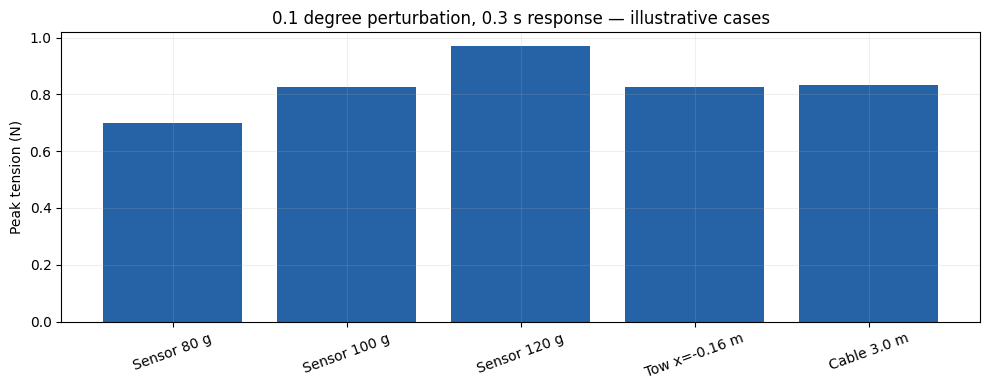

In [3]:
fig, ax = plt.subplots()
labels=['Sensor 80 g','Sensor 100 g','Sensor 120 g','Tow x=-0.16 m','Cable 3.0 m']
ax.bar(labels,sweep['max_tension_N'],color='#2563a6')
ax.set(ylabel='Peak tension (N)',title='0.1 degree perturbation, 0.3 s response — illustrative cases')
ax.tick_params(axis='x',labelrotation=20);fig.tight_layout();plt.show()

## 수치 수렴 기록

In [4]:
report = json.loads((ROOT/'outputs/validation/convergence/convergence.json').read_text())
print(report['case'])
pd.DataFrame(report['checks'])

fixed-length tow, sensor pitch perturbed by 0.1 deg; contact is not excited


,metric,status,relative_changes,values
0,max_tension_N,pass,"[0.0002514662568180816, 7.483020640655842e-05,...","[0.8271892605619796, 0.8273973230697133, 0.827..."
1,max_pitch_change_deg,pass,"[0.010729652185125749, 0.0028997719292573583, ...","[5.340715472756941e-06, 5.284019778395432e-06,..."
2,contact_impulse_Ns,not_excited,NaN,"[0.0, 0.0, 0.0, 0.0]"
3,max_contact_N,not_excited,NaN,"[0.0, 0.0, 0.0, 0.0]"


## 전 과정 수렴 검사

In [5]:
full = json.loads((ROOT/'outputs/mission_convergence/convergence.json').read_text())
print('All checks passed:', full['all_numerical_checks_pass'])
print('Same capture outcome:', full['same_capture_outcome'])
pd.DataFrame(full['checks'])

All checks passed: False
Same capture outcome: False


,metric,status,values,relative_changes
0,max_tension_N,fail,"[12.017876838570404, 7.560129939469972, 8.1318...","[0.5896389261548799, 0.07030289543992746, 0.0]"
1,max_pitch_change_deg,fail,"[18.040030599115845, 17.533153279681652, 18.63...","[0.028909649698984182, 0.05931028177655592, 0.0]"
2,contact_impulse_Ns,fail,"[1.4935128684151384, 2.0619113057607295, 1.523...","[0.2756658037411963, 0.35360216073718165, 0.0]"
3,max_contact_N,fail,"[3.4025408678990763, 3.1487991090501244, 4.667...","[0.0805836606468986, 0.3254207918263547, 0.0]"
4,max_capture_N,fail,"[0.0, 0.0, 5.735788033980003, 5.735788033980003]","[0.0, 1.0, 0.0]"


## 회수 구간 시간 간격 비교

In [6]:
recovery_time = json.loads((ROOT/'outputs/recovery_time_convergence/convergence.json').read_text())
print(recovery_time['scope'])
pd.DataFrame(recovery_time['checks'])

40-cell recovery branch from identical saved state at 9 s; not a full-cycle mesh check


,metric,values,relative_change,status
0,max_tension_N,"[8.427459536168795, 8.42973175657908]",0.000270,pass
1,max_pitch_change_deg,"[2.5106614579286077, 2.510652090211133]",0.000004,pass
2,contact_impulse_Ns,"[0.32722375834054873, 0.3274520859175197]",0.000697,pass
3,max_contact_N,"[5.321933513489191, 5.322682314527004]",0.000141,pass
4,max_capture_N,"[5.738074614691076, 5.7329645864812795]",0.000891,pass


## 판독

고정 길이 견인에서 통과한 검사는 전개·접촉·포획의 수렴성을 대신하지 않습니다. 접촉이 발생하지 않은 값은 `not_excited`로 표시하며 통과로 세지 않습니다. 전체 임무의 수렴성은 `scripts/run_mission_matrix.py`가 만드는 별도 기록에서 확인합니다.